In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import json
from pathlib import Path


In [2]:
df = pd.read_csv('/home/hieule/research/reflector-position/results/experiments/memetic_hparam_sweep/sweep_summary.csv')

In [3]:
df.head()

,trial_name,status,rank_by_best_primary_loss,ga_best_primary_loss,ga_best_softmin_loss,ga_best_coverage_loss,ga_best_repulsion_loss,ga_best_mean_rssi,ga_best_min_rssi,ga_best_p5_rssi,...,total_duration_sec,runner_wall_clock_sec,num_ga_seeds,num_gd_tasks,num_gd_results,best_primary_loss,best_primary_fitness,output_dir,error,overrides_json
0,baseline_current_config,ok,2,127.838753,129.140152,-1.0,NaN,-74.725708,-102.327179,-92.969376,...,238.875496,242.514393,5,5,5,127.508575,-127.838753,/home/hieule/research/reflector-position/resul...,NaN,"{""verbose"": true}"
1,gd_lr_temp_alpha_001_learning_rate_0p01_softmi...,ok,3,148.197235,149.704269,-1.0,NaN,-74.824326,-105.647278,-92.639626,...,239.390531,242.691783,5,5,5,148.364700,-148.197235,/home/hieule/research/reflector-position/resul...,NaN,"{""gd_optimization_params"": {""learning_rate"": 0..."
2,ga_pop_mut_001_pop_size_100_n_gen_20_mutpb_0p7,ok,1,127.559212,128.857788,-1.0,NaN,-75.711960,-102.105743,-91.423965,...,212.168550,215.406085,5,5,5,127.387032,-127.559212,/home/hieule/research/reflector-position/resul...,NaN,"{""ga_params"": {""mutpb"": 0.7, ""n_gen"": 20, ""pop..."


In [4]:
# ── Load trend CSVs (one per trial) ──────────────────────────────────────────
SWEEP_DIR = Path('/home/hieule/research/reflector-position/results/experiments/memetic_hparam_sweep')
TRENDS_DIR = SWEEP_DIR / 'trends'

gd_histories = {}    # trial_name -> DataFrame
ga_generations = {}  # trial_name -> DataFrame

if TRENDS_DIR.exists():
    for p in sorted(TRENDS_DIR.glob('*_gd_history.csv')):
        trial = p.stem.replace('_gd_history', '')
        gd_histories[trial] = pd.read_csv(p)
    for p in sorted(TRENDS_DIR.glob('*_ga_generations.csv')):
        trial = p.stem.replace('_ga_generations', '')
        ga_generations[trial] = pd.read_csv(p)

print(f"GD trend files loaded : {len(gd_histories)}")
print(f"GA trend files loaded : {len(ga_generations)}")


GD trend files loaded : 3
GA trend files loaded : 3


In [5]:
# ── Summary / ranking table ───────────────────────────────────────────────────
RANK_COLS = [
    'trial_name',
    'ga_best_primary_loss',
    'gd_initial_primary_loss', 'gd_best_primary_loss', 'gd_final_primary_loss',
    'ga_best_mean_rssi', 'ga_best_min_rssi', 'ga_best_p5_rssi', 'ga_best_coverage_pct',
    'gd_best_mean_rssi',  'gd_best_min_rssi',  'gd_best_p5_rssi',  'gd_best_coverage_pct',
    'gd_final_mean_rssi', 'gd_final_min_rssi', 'gd_final_p5_rssi', 'gd_final_coverage_pct',
    'total_time_s',
]

available = [c for c in RANK_COLS if c in df.columns]
df_rank = df[available].sort_values('gd_best_primary_loss', ascending=True).reset_index(drop=True)
df_rank.index += 1  # 1-based rank

# Highlight float columns with a gradient
float_cols = df_rank.select_dtypes(include='number').columns.tolist()
df_rank.style \
    .background_gradient(subset=['gd_best_primary_loss'], cmap='RdYlGn_r') \
    .background_gradient(subset=[c for c in float_cols if 'rssi' in c], cmap='RdYlGn') \
    .format({c: '{:.4f}' for c in float_cols}) \
    .set_caption('Trials ranked by GD best primary loss (lower = better)')


,trial_name,ga_best_primary_loss,gd_initial_primary_loss,gd_best_primary_loss,gd_final_primary_loss,ga_best_mean_rssi,ga_best_min_rssi,ga_best_p5_rssi,ga_best_coverage_pct,gd_best_mean_rssi,gd_best_min_rssi,gd_best_p5_rssi,gd_best_coverage_pct,gd_final_mean_rssi,gd_final_min_rssi,gd_final_p5_rssi,gd_final_coverage_pct
1,ga_pop_mut_001_pop_size_100_n_gen_20_mutpb_0p7,127.5592,128.3867,127.3870,127.3870,-75.7120,-102.1057,-91.4240,100.0000,-75.0015,-102.0556,-91.4475,100.0000,-75.0015,-102.0556,-91.4475,100.0000
2,baseline_current_config,127.8388,128.0121,127.5086,127.5637,-74.7257,-102.3272,-92.9694,100.0000,-73.7827,-107.5452,-92.3697,100.0000,-73.7729,-107.5374,-93.1409,100.0000
3,gd_lr_temp_alpha_001_learning_rate_0p01_softmin_temperature_0p1_alpha_0p99,148.1972,148.8508,148.3647,148.6133,-74.8243,-105.6473,-92.6396,100.0000,-74.1183,-109.7493,-93.5476,100.0000,-74.0949,-112.9339,-93.8637,100.0000


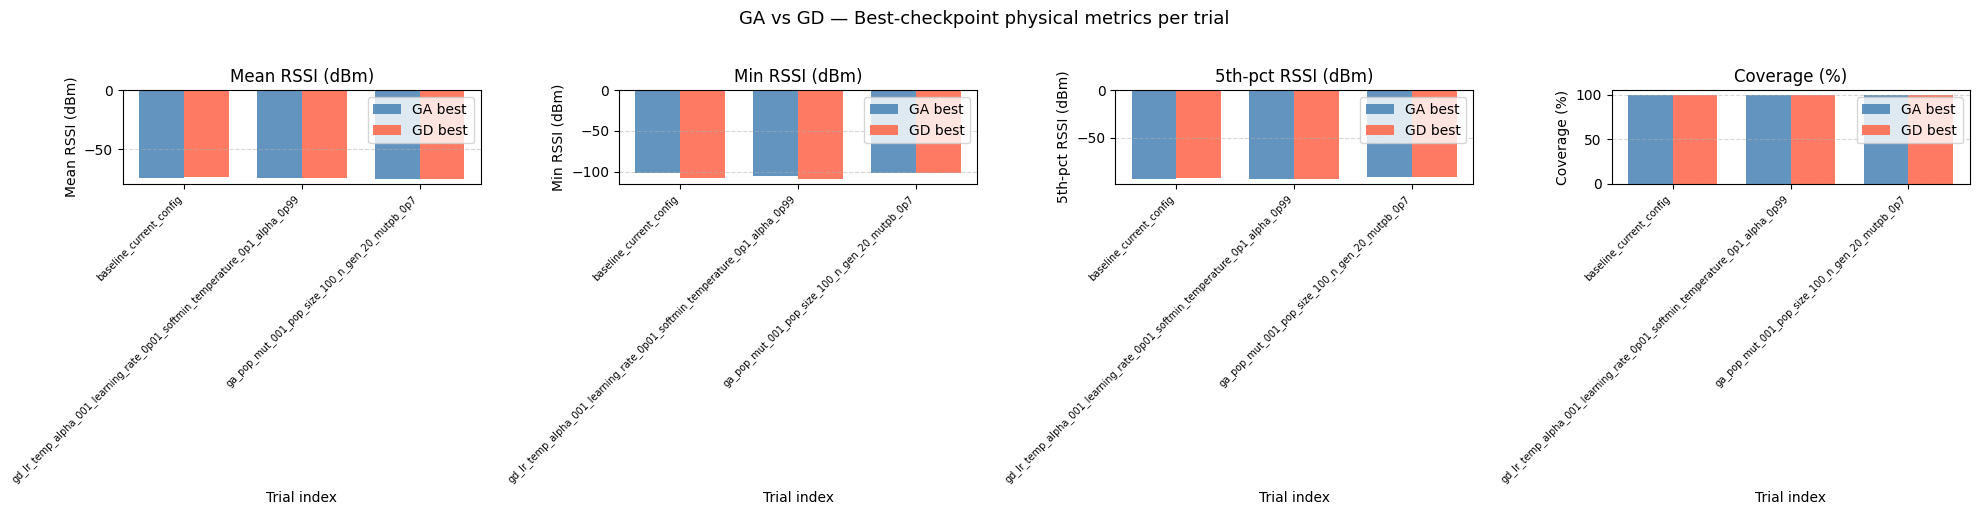

In [6]:
# ── GA vs GD comparison — best-checkpoint physical metrics ───────────────────
METRIC_PAIRS = [
    ('ga_best_mean_rssi',     'gd_best_mean_rssi',     'Mean RSSI (dBm)'),
    ('ga_best_min_rssi',      'gd_best_min_rssi',      'Min RSSI (dBm)'),
    ('ga_best_p5_rssi',       'gd_best_p5_rssi',       '5th-pct RSSI (dBm)'),
    ('ga_best_coverage_pct',  'gd_best_coverage_pct',  'Coverage (%)'),
]

valid_pairs = [(a, b, label) for a, b, label in METRIC_PAIRS
               if a in df.columns and b in df.columns]

if valid_pairs:
    n_metrics = len(valid_pairs)
    fig, axes = plt.subplots(1, n_metrics, figsize=(5 * n_metrics, 5))
    if n_metrics == 1:
        axes = [axes]

    x = np.arange(len(df))
    width = 0.38

    for ax, (ga_col, gd_col, label) in zip(axes, valid_pairs):
        ax.bar(x - width / 2, df[ga_col], width, label='GA best', color='steelblue', alpha=0.85)
        ax.bar(x + width / 2, df[gd_col], width, label='GD best', color='tomato',    alpha=0.85)
        ax.set_xlabel('Trial index')
        ax.set_ylabel(label)
        ax.set_title(label)
        ax.set_xticks(x)
        ax.set_xticklabels(df['trial_name'] if 'trial_name' in df.columns else x,
                           rotation=45, ha='right', fontsize=7)
        ax.legend()
        ax.grid(axis='y', linestyle='--', alpha=0.5)

    fig.suptitle('GA vs GD — Best-checkpoint physical metrics per trial', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No GA/GD metric columns in the CSV — run the sweep first.")


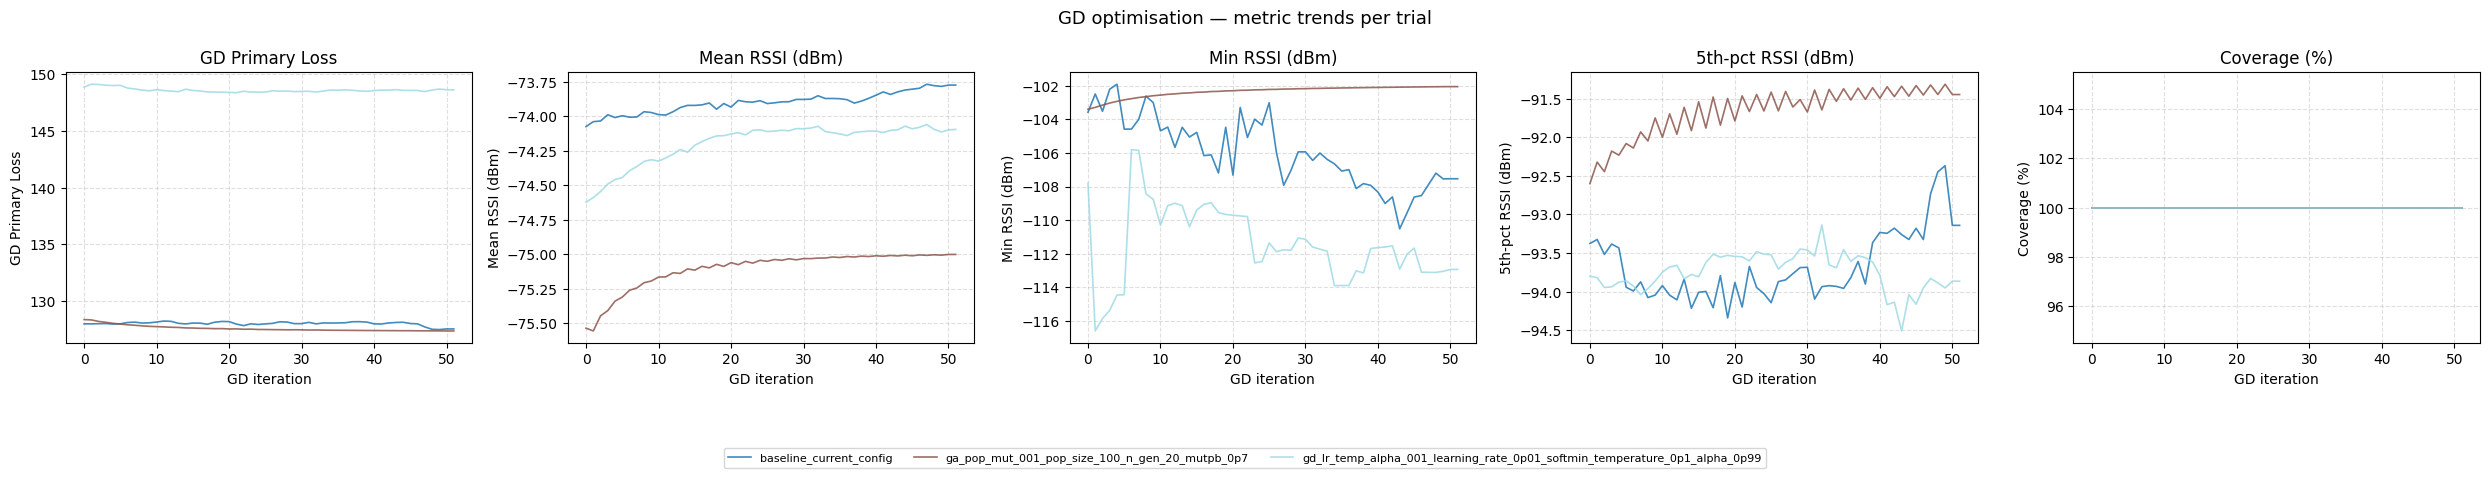

In [7]:
# ── GD iteration history — loss and RSSI trends per trial ────────────────────
if gd_histories:
    GD_TREND_METRICS = [
        ('primary_loss',  'GD Primary Loss'),
        ('mean_rssi',     'Mean RSSI (dBm)'),
        ('min_rssi',      'Min RSSI (dBm)'),
        ('p5_rssi',       '5th-pct RSSI (dBm)'),
        ('coverage_pct',  'Coverage (%)'),
    ]

    n_plots = len(GD_TREND_METRICS)
    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4))
    colors = cm.tab20(np.linspace(0, 1, len(gd_histories)))

    for ax, (col, ylabel) in zip(axes, GD_TREND_METRICS):
        for (trial, hist), color in zip(gd_histories.items(), colors):
            if col in hist.columns:
                ax.plot(hist['step'], hist[col], label=trial, color=color, linewidth=1.2, alpha=0.85)
        ax.set_xlabel('GD iteration')
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)
        ax.grid(linestyle='--', alpha=0.4)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=min(4, len(gd_histories)),
               bbox_to_anchor=(0.5, -0.18), fontsize=8)
    fig.suptitle('GD optimisation — metric trends per trial', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("No GD history trend files found in", TRENDS_DIR)


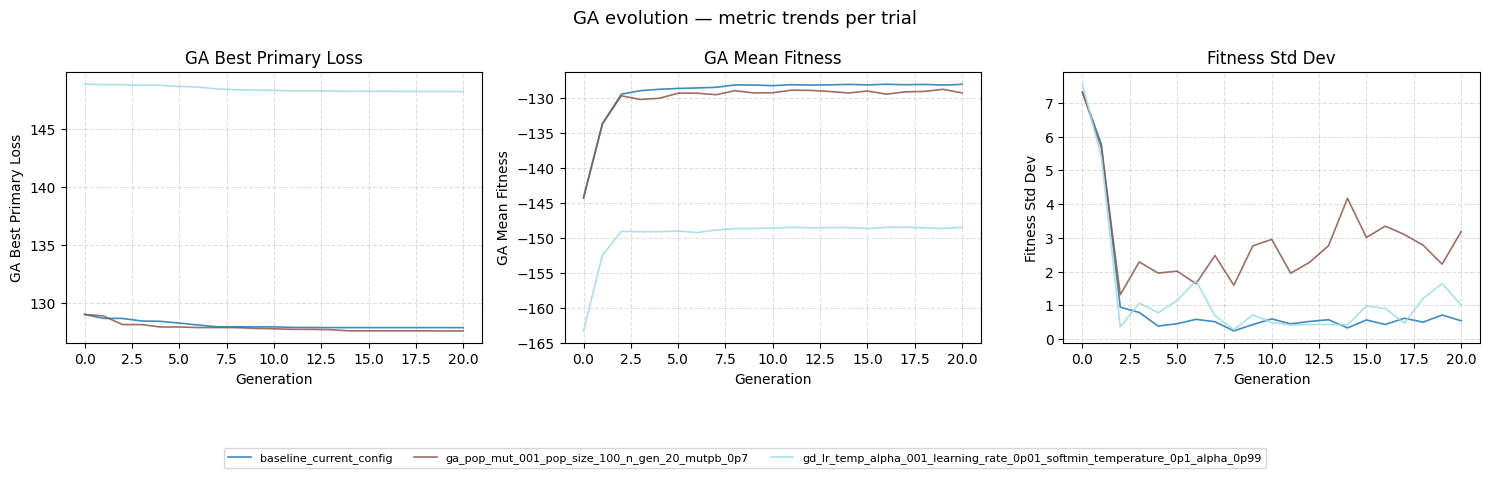

In [8]:
# ── GA generation history — evolution trends per trial ───────────────────────
if ga_generations:
    GA_TREND_METRICS = [
        ('best_primary_loss',   'GA Best Primary Loss'),
        ('mean_primary_fitness','GA Mean Fitness'),
        ('std',                 'Fitness Std Dev'),
    ]

    n_plots = len(GA_TREND_METRICS)
    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4))
    colors = cm.tab20(np.linspace(0, 1, len(ga_generations)))

    for ax, (col, ylabel) in zip(axes, GA_TREND_METRICS):
        for (trial, hist), color in zip(ga_generations.items(), colors):
            if col in hist.columns:
                ax.plot(hist['gen'], hist[col], label=trial, color=color, linewidth=1.2, alpha=0.85)
        ax.set_xlabel('Generation')
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)
        ax.grid(linestyle='--', alpha=0.4)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=min(4, len(ga_generations)),
               bbox_to_anchor=(0.5, -0.18), fontsize=8)
    fig.suptitle('GA evolution — metric trends per trial', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("No GA generation trend files found in", TRENDS_DIR)


Best trial: ga_pop_mut_001_pop_size_100_n_gen_20_mutpb_0p7


,primary_loss,softmin_loss,coverage_loss,repulsion_loss,mean_rssi,min_rssi,p5_rssi,coverage_pct
checkpoint,,,,,,,,
GA best,127.5592,128.8578,-1.0000,nan,-75.7120,-102.1057,-91.4240,100.0000
GD initial,128.3867,129.6936,-1.0000,0.0000,-75.5365,-103.4023,-92.6005,100.0000
GD best,127.3870,128.6839,-1.0000,0.0000,-75.0015,-102.0556,-91.4475,100.0000
GD final,127.3870,128.6839,-1.0000,0.0000,-75.0015,-102.0556,-91.4475,100.0000


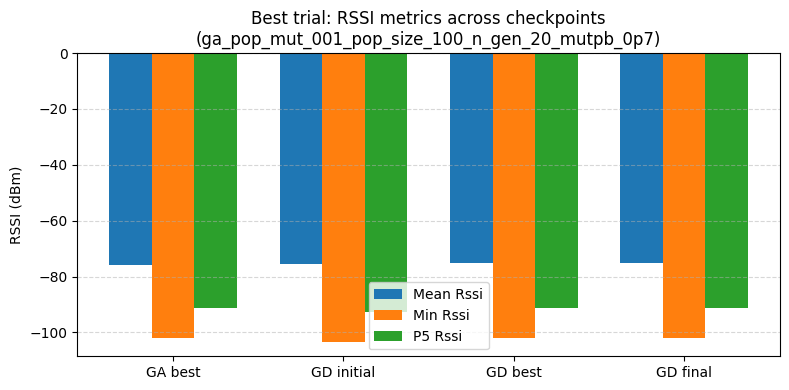

In [9]:
# ── Best trial deep-dive: GA best + GD initial → best → final ────────────────
if 'gd_best_primary_loss' in df.columns and len(df) > 0:
    best_row = df.loc[df['gd_best_primary_loss'].idxmin()]
    best_name = best_row.get('trial_name', str(df['gd_best_primary_loss'].idxmin()))
    print(f"Best trial: {best_name}")

    CHECKPOINT_GROUPS = {
        'GA best':   {'prefix': 'ga_best_'},
        'GD initial':{'prefix': 'gd_initial_'},
        'GD best':   {'prefix': 'gd_best_'},
        'GD final':  {'prefix': 'gd_final_'},
    }
    FIELDS = ['primary_loss', 'softmin_loss', 'coverage_loss', 'repulsion_loss',
              'mean_rssi', 'min_rssi', 'p5_rssi', 'coverage_pct']

    records = []
    for label, cfg in CHECKPOINT_GROUPS.items():
        row = {'checkpoint': label}
        for f in FIELDS:
            col = cfg['prefix'] + f
            row[f] = best_row.get(col, np.nan)
        records.append(row)

    df_deep = pd.DataFrame(records).set_index('checkpoint')

    # Styled table
    float_c = df_deep.select_dtypes('number').columns.tolist()
    display_df = df_deep.style \
        .background_gradient(subset=['primary_loss'], cmap='RdYlGn_r') \
        .background_gradient(subset=[c for c in float_c if 'rssi' in c], cmap='RdYlGn') \
        .format({c: '{:.4f}' for c in float_c}) \
        .set_caption(f'Best trial: {best_name} — all checkpoint metrics')
    display(display_df)

    # Bar chart for RSSI metrics across checkpoints
    rssi_cols = ['mean_rssi', 'min_rssi', 'p5_rssi']
    rssi_data = df_deep[rssi_cols].dropna(how='all')
    if not rssi_data.empty:
        x = np.arange(len(rssi_data))
        width = 0.25
        fig, ax = plt.subplots(figsize=(8, 4))
        for i, col in enumerate(rssi_cols):
            ax.bar(x + i * width, rssi_data[col], width, label=col.replace('_', ' ').title())
        ax.set_xticks(x + width)
        ax.set_xticklabels(rssi_data.index)
        ax.set_ylabel('RSSI (dBm)')
        ax.set_title(f'Best trial: RSSI metrics across checkpoints\n({best_name})')
        ax.legend()
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()
else:
    print("Run the sweep and reload to see best-trial deep-dive.")
